In [1]:
import os
from functools import reduce

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
torch.set_default_dtype(torch.float32)

from src.cann.models.minimal import Minimal
from src.cann.models.polykan import PolyKAN
from src.cann.models.base import ActNN
from src.cann.train import ACT_DICT

In [3]:
! ls ../results/*knockout* -d

../results/asigmoid_act_knockout_coef_l1_1
../results/asigmoid_no_knockout_l1_1
../results/asigmoid_weight_knockout_neur_l1_1
../results/poly_act_knockout_coef_l1_1
../results/poly_no_knockout_l1_1
../results/poly_weight_knockout_neur_l1_1
../results/prelu_act_knockout_coef_l1_1
../results/prelu_no_knockout_l1_1
../results/prelu_weight_knockout_neur_l1_1


In [5]:
root_dir = "../results"

dir_list = [
    "prelu_no_knockout_l1_1",\
    "prelu_weight_knockout_neur_l1_1",\
    "prelu_act_knockout_coef_l1_1"
    ]

labels = [
    "PReLU Full",\
    "PReLU Static Neurons",\
    "PReLU Static Activations"
    ]


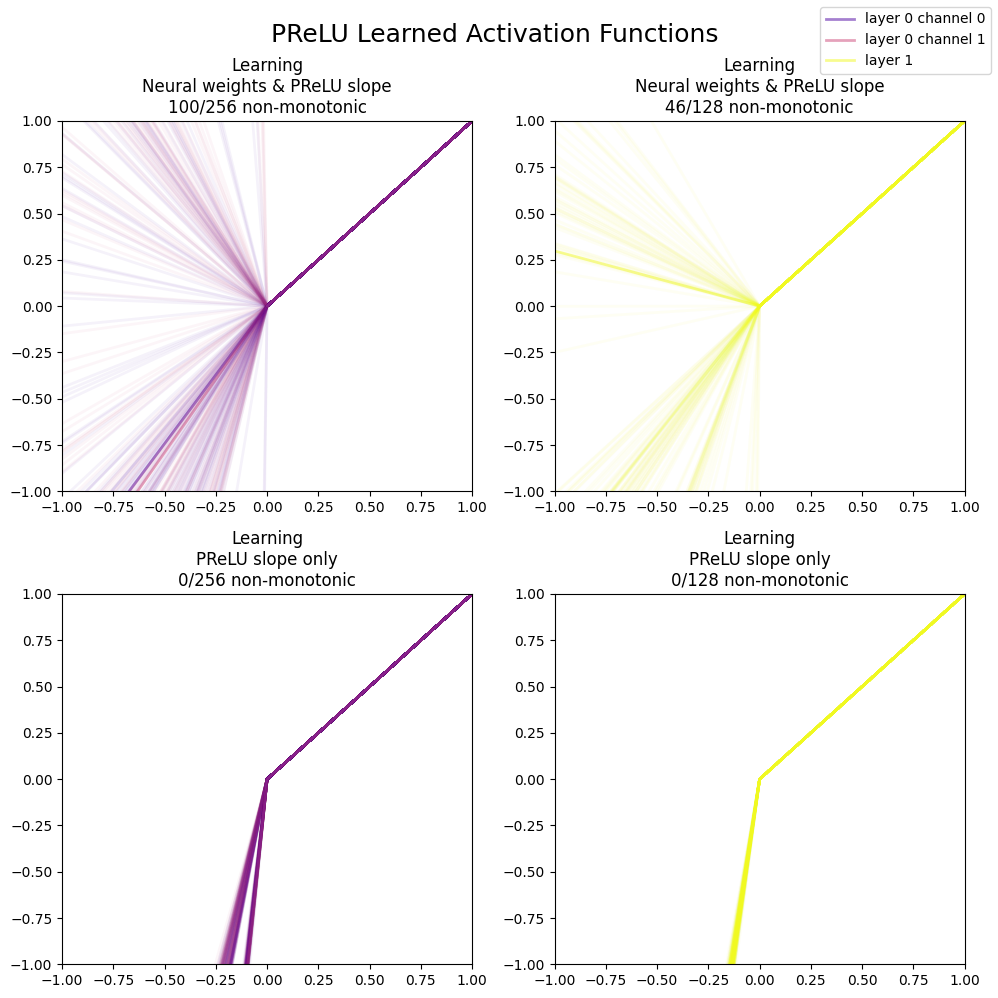

In [204]:
root_dir = "../results"

dir_list = [
    "prelu_no_knockout_l1_1",\
    "prelu_weight_knockout_neur_l1_1"
    ]

labels = [
    "Neural weights & PReLU slope",\
    "PReLU slope only"
    ]


fig, ax = plt.subplots(2,2,figsize=(10,10))

x = torch.arange(-1, 1, 0.01)* torch.ones(1,2,1,1)
run_index = 0
param_index = -1
act_name = "prelu"

lw=2
my_cmap = plt.get_cmap("plasma")
colora = my_cmap(32)
colorb = my_cmap(128)
colorc = my_cmap(256)


for label_index, fn in enumerate(dir_list):
    filepath = os.path.join(root_dir, fn, "exp.csv")
    
    first_0 = 0
    total_layer_0 = 0
    nonmono_layer_0 = 0
    total_layer_1 = 0
    nonmono_layer_1 = 0 
    
    df = pd.read_csv(filepath)
    del df["Unnamed: 0"]
    
    for run_index in range(len(df)):
        
        model_width = df["model_width"][run_index].item()
        model_depth = df["model_depth"][run_index].item()
        activation_name = df["activation_name"][run_index].lower()
        
        run_df = pd.read_csv(os.path.join("..", df["run_filename"][run_index]))
        del run_df["Unnamed: 0"]
    
        parameters = np.load(os.path.join("..", run_df["parameters_filename"][0]))
        
        if activation_name == "polykan":
            model = PolyKAN(width=model_width, depth=model_depth)
        else:
            model = ActNN(width=model_width, depth=model_depth, activation=ACT_DICT[activation_name])
    
        model.set_parameters(parameters[param_index])
        
        act_params = list(model.activations.parameters())
        
        total_layer_0 += reduce(lambda a,b :a*b, act_params[0].shape)
        total_layer_1 += reduce(lambda a,b :a*b, act_params[1].shape)

        nonmono_layer_0 += (1 * (act_params[0] < 0)).sum()
        nonmono_layer_1 += (1 * (act_params[1] < 0)).sum()
        
        with torch.no_grad():
            for act_index in range(len(model.activations)):
                if act_index == 0:
                    y = model.activations[act_index](x)
                    
                    if first_0:
                        label = f"_layer {act_index}"
                        alpha = 0.05
                    else:
                        label = f"layer {act_index}"
                        alpha = 0.5
                    
                    ax[label_index,act_index].plot(x[0,0,0,:], y[0,0,0,:], color=colora, lw=lw, alpha=alpha,\
                            label=f"{label} channel 0")
                    ax[label_index,act_index].plot(x[0,0,0,:], y[0,1,0,:], color=colorb, lw=lw,  alpha=alpha,\
                            label=f"{label} channel 1")
                    
                else:
                    
                    if first_0:
                        label = f"_layer {act_index}"
                        alpha = 0.05
                    else:
                        label = f"layer {act_index}"
                        alpha = 0.5
                    
                    y = model.activations[act_index](x[:,0:1,:,:])
                    
                    ax[label_index,act_index].plot(x[0,0,0,:], y[0,0,0,:],  color=colorc,  lw=lw, alpha=alpha, label=label)
                   
            first_0 += 1

        
    title_a = f"Learning\n{labels[label_index]}\n{nonmono_layer_0}/{total_layer_0} non-monotonic"
    title_b = f"Learning\n{labels[label_index]}\n{nonmono_layer_1}/{total_layer_1} non-monotonic"
    
    ax[label_index,0].set_title(title_a)
    ax[label_index,1].set_title(title_b)
        
    ax[label_index,0].axis([-1,1,-1,1])
    ax[label_index,1].axis([-1,1,-1,1])
    if label_index == 0:
        fig.legend() #["1st FC layer", "", "2nd FC layer"])
fig.suptitle("PReLU Learned Activation Functions",fontsize=18)
plt.tight_layout()
plt.savefig("prelu_monotony.png")
plt.show()

# act_params[1]

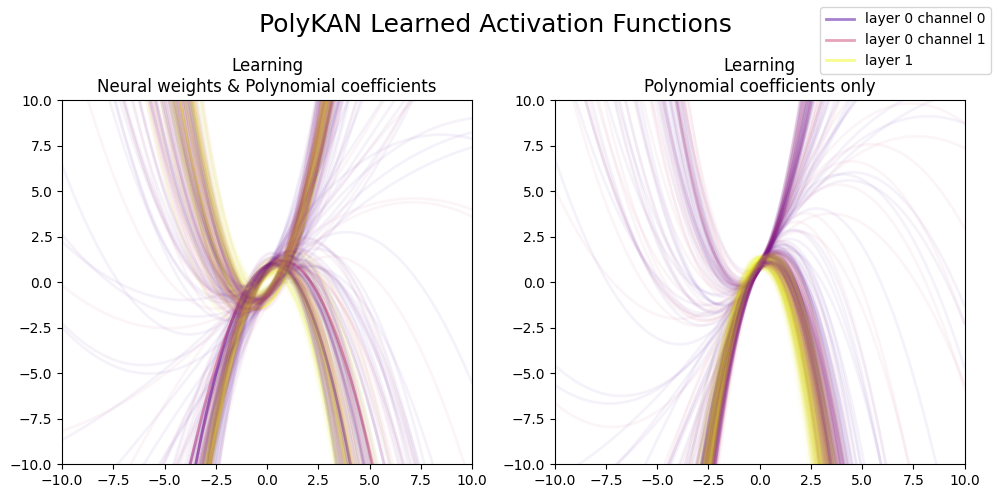

In [210]:
root_dir = "../results"

dir_list = [
    "prelu_no_knockout_l1_1",\
    "prelu_weight_knockout_neur_l1_1"
    ]


dir_list = [\
    "poly_no_knockout_l1_1",\
    "poly_weight_knockout_neur_l1_1"]

labels = [
    "PReLU Full",\
    "PReLU Static Neurons"
    ]


fig, ax = plt.subplots(1,2,figsize=(10,5))

x = torch.arange(-10, 10, 0.01)* torch.ones(1,2,1,1)
run_index = 0
param_index = -1
act_name = "prelu"

lw=2
my_cmap = plt.get_cmap("plasma")
colora = my_cmap(32)
colorb = my_cmap(128)
colorc = my_cmap(256)

first_0 = 0

for fn in dir_list:
    filepath = os.path.join(root_dir, fn, "exp.csv")

    df = pd.read_csv(filepath)
    del df["Unnamed: 0"]
    
    for run_index in range(len(df)):
        
        model_width = df["model_width"][run_index].item()
        model_depth = df["model_depth"][run_index].item()
        activation_name = df["activation_name"][run_index].lower()
        
        run_df = pd.read_csv(os.path.join("..", df["run_filename"][run_index]))
        del run_df["Unnamed: 0"]
    
        parameters = np.load(os.path.join("..", run_df["parameters_filename"][0]))
        
        if activation_name == "polykan":
            model = PolyKAN(width=model_width, depth=model_depth)
        else:
            model = ActNN(width=model_width, depth=model_depth, activation=ACT_DICT[activation_name])
    
        model.set_parameters(parameters[param_index])
        
        
            
        with torch.no_grad():
            for act_index in range(len(model.activations)):
                if act_index == 0:
                    y = model.activations[act_index](x)
                    
                    if first_0:
                        label = f"_layer {act_index}"
                        alpha = 0.05
                    else:
                        label = f"layer {act_index}"
                        alpha = 0.5
                    
                    if "no_knockout" in fn:
                        ax[0].plot(x[0,0,0,:], y[0,0,0,:], color=colora, lw=lw, alpha=alpha,\
                                label=f"{label} channel 0")
                        ax[0].plot(x[0,0,0,:], y[0,1,0,:], color=colorb, lw=lw,  alpha=alpha,\
                                label=f"{label} channel 1")
                    elif "weight_knockout" in fn:
                        ax[1].plot(x[0,0,0,:], y[0,0,0,:], color=colora,  lw=lw, alpha=alpha,\
                                label=f"{label} channel 0")
                        ax[1].plot(x[0,0,0,:], y[0,1,0,:], color=colorb,  lw=lw, alpha=alpha,\
                                label=f"{label} channel 1")
                    if "act_knockout" in fn:
                        ax[2].plot(x[0,0,0,:], y[0,0,0,:], color=colora, lw=lw,  alpha=alpha,\
                                label=f"{label} channel 0")
                        ax[2].plot(x[0,0,0,:], y[0,1,0,:], color=colorb,  lw=lw, alpha=alpha,\
                                label=f"{label} channel 1")
                else:
                    
                    if first_0:
                        label = f"_layer {act_index}"
                        alpha = 0.05
                    else:
                        label = f"layer {act_index}"
                        alpha = 0.5
                    
                    y = model.activations[act_index](x[:,0:1,:,:])
                    
                    if "no_knockout" in fn:
                        ax[0].plot(x[0,0,0,:], y[0,0,0,:],  color=colorc,  lw=lw, alpha=alpha, label=label)
                    elif "weight_knockout" in fn:
                        ax[1].plot(x[0,0,0,:], y[0,0,0,:],  color=colorc, lw=lw, alpha=alpha, label=label)
                    if "act_knockout" in fn:
                        ax[2].plot(x[0,0,0,:], y[0,0,0,:],  color=colorc, lw=lw, alpha=alpha, label=label)

            first_0 += 1
        
title_a = "Learning\nNeural weights & Polynomial coefficients"
title_b = "Learning\nPolynomial coefficients only"

ax[0].set_title(title_a)
ax[1].set_title(title_b)
ax[0].axis([-10,10,-10,10])
ax[1].axis([-10,10,-10,10])
fig.legend() #["1st FC layer", "", "2nd FC layer"])
fig.suptitle("PolyKAN Learned Activation Functions",fontsize=18)
plt.tight_layout()
plt.savefig("polykan_activation_functions.png")
plt.show()

In [140]:
import torch.nn as nn
help(nn.PReLU())

Help on PReLU in module torch.nn.modules.activation object:

class PReLU(torch.nn.modules.module.Module)
 |  PReLU(num_parameters: int = 1, init: float = 0.25, device=None, dtype=None) -> None
 |
 |  Applies the element-wise PReLU function.
 |
 |  .. math::
 |      \text{PReLU}(x) = \max(0,x) + a * \min(0,x)
 |
 |  or
 |
 |  .. math::
 |      \text{PReLU}(x) =
 |      \begin{cases}
 |      x, & \text{ if } x \ge 0 \\
 |      ax, & \text{ otherwise }
 |      \end{cases}
 |
 |  Here :math:`a` is a learnable parameter. When called without arguments, `nn.PReLU()` uses a single
 |  parameter :math:`a` across all input channels. If called with `nn.PReLU(nChannels)`,
 |  a separate :math:`a` is used for each input channel.
 |
 |
 |  .. note::
 |      weight decay should not be used when learning :math:`a` for good performance.
 |
 |  .. note::
 |      Channel dim is the 2nd dim of input. When input has dims < 2, then there is
 |      no channel dim and the number of channels = 1.
 |
 |  Args:

In [70]:
fig, ax = plt.subplots(1,3,figsize=(16,4))

x = torch.arange(-.1, .1, 0.0001)* torch.ones(1,2,1,1)
run_index = 0
param_index = -1
act_name = "prelu"

lw=2
my_cmap = plt.get_cmap("plasma")
colora = my_cmap(196)
colorb = my_cmap(32)

for fn in dir_list:
    filepath = os.path.join(root_dir, fn, "exp.csv")

    df = pd.read_csv(filepath)
    del df["Unnamed: 0"]
    
    for run_index in range(len(df)):
        
        model_width = df["model_width"][run_index].item()
        model_depth = df["model_depth"][run_index].item()
        activation_name = df["activation_name"][run_index].lower()
        
        run_df = pd.read_csv(os.path.join("..", df["run_filename"][run_index]))
        del run_df["Unnamed: 0"]
    
        parameters = np.load(os.path.join("..", run_df["parameters_filename"][0]))
        
        if activation_name == "polykan":
            model = PolyKAN(width=model_width, depth=model_depth)
        else:
            model = ActNN(width=model_width, depth=model_depth, activation=ACT_DICT[activation_name])
    
        model.set_parameters(parameters[param_index])
        
        with torch.no_grad():
            for act_index in range(len(model.activations)):
                if act_index == 0:
                    y = model.activations[act_index](x)
                    
                    if "no_knockout" in fn:
                        ax[0].plot(x[0,0,0,:], y[0,0,0,:], color=colora, lw=lw, alpha=0.1)
                        ax[0].plot(x[0,0,0,:], y[0,1,0,:], color=colora, lw=lw,  alpha=0.1)
                    elif "weight_knockout" in fn:
                        ax[1].plot(x[0,0,0,:], y[0,0,0,:], color=colora,  lw=lw, alpha=0.1)
                        ax[1].plot(x[0,0,0,:], y[0,1,0,:], color=colora,  lw=lw, alpha=0.1)
                    if "act_knockout" in fn:
                        ax[2].plot(x[0,0,0,:], y[0,0,0,:], color=colora, lw=lw,  alpha=0.1)
                        ax[2].plot(x[0,0,0,:], y[0,1,0,:], color=colora,  lw=lw, alpha=0.1)
                else:
                    
                    y = model.activations[act_index](x[:,0:1,:,:])
                    
                    if "no_knockout" in fn:
                        ax[0].plot(x[0,0,0,:], y[0,0,0,:],  color=colorb,  lw=lw, alpha=0.05)
                    elif "weight_knockout" in fn:
                        ax[1].plot(x[0,0,0,:], y[0,0,0,:],  color=colorb, lw=lw, alpha=0.05)
                    if "act_knockout" in fn:
                        ax[2].plot(x[0,0,0,:], y[0,0,0,:],  color=colorb, lw=lw, alpha=0.05)
        
title_a = "Learning\nNeural weights & PReLU slope"
title_b = "Learning\nPReLU slope only"
title_c = "Learning\nNeural weights only"

ax[0].set_title(title_a)
ax[1].set_title(title_b)
ax[2].set_title(title_c)
ax[0].axis([-0.1,0.1,-0.1,0.1])
ax[1].axis([-0.1,0.1,-0.1,0.1])
ax[2].axis([-0.1,0.1,-0.1,0.1])
fig.legend(["1st FC layer", "", "2nd FC layer"])

plt.show()

ActNN(
  (layers): ModuleList(
    (0): Conv2d(1, 2, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
    (1): Conv2d(2, 1, kernel_size=(1, 1), stride=(1, 1))
  )
  (activations): ModuleList(
    (0): PReLU(num_parameters=2)
    (1): PReLU(num_parameters=1)
  )
  (output_conv): Conv2d(1, 1, kernel_size=(1, 1), stride=(1, 1))
)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
my_cmap = plt.get_cmap("plasma")
#labels = []
label_locs = []
bar_width = 4
bar_slices = 3


idx = 0
idx_a = 0
idx_b = 0

for fn in dir_list:
    if "knockout" in fn:
        filepath = os.path.join(root_dir, fn, "exp.csv")
        df = pd.read_csv(filepath)
            
        accuracy = (df["final_grid_accuracy"] == 1.0).mean()
        number_runs = len(df)
        
        label = fn #os.path.split(os.path.split(fn)[0])[1]
        
        p = ax.bar(bar_width*idx_a+bar_width/bar_slices*idx_b, accuracy, \
                   width=bar_width/bar_slices,  color=my_cmap(16*idx), label=label)
        
        ax.bar_label(p, labels=[f"{number_runs} runs\n{accuracy:.3f} success"], label_type="edge", rotation=60)
        #ax.bar_label(p, labels=[f"{accuracy:.3f}"], label_type="edge", rotation=60)
        
        label_locs.append(bar_width*idx_a+ bar_width/bar_slices*idx_b)
        
        #labels.append(label)
        if "Activations" in labels[idx]:
            idx_a += 1
            idx_b = 0
            
        idx_b += 1
        idx += 1
        
    #plt.legend()
ax.axis([-bar_width/bar_slices, idx_a*bar_width+bar_width/bar_slices, 0, 1.7])
ax.set_xticks(label_locs)
ax.set_xticklabels(labels, rotation=90)
ax.set_title(f"Neural and activation learning knockouts\nL(1,1) networks, {number_runs} runs")
plt.tight_layout()
plt.savefig("knockout_poly_prelu.png")
plt.show()
